In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Paths are relative to this notebook's directory.
data_path = Path("../data/processed/cases.csv")
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

cases = pd.read_csv(data_path)

In [2]:
print("Shape:", cases.shape)
cases.head()

Shape: (8419, 5)


,text,issue,issue_area,case_name,year
0,[ Halliburton Oil Well Cementing Co. v. Walker...,80180.0,8,HALLIBURTON OIL WELL CEMENTING CO. v. WALKER e...,1946
1,"Rehearing Denied Dec. 16, 1946. See . Mr.Claud...",10500.0,1,CLEVELAND v. UNITED STATES,1946
2,"Rehearing Denied Dec. 16, 1946\n See .\n Appea...",80250.0,8,CHAMPLIN REFINING CO. v. UNITED STATES ET AL.,1946
3,"Mr.\nWalter J. Cummings, Jr., of Washington, D...",20150.0,2,UNITED STATES v. ALCEA BAND OF TILLAMOOKS ET AL.,1946
4,"Mr.A. Devitt Vaneck, of Washington, D.C., for ...",80060.0,8,"UNITED STATES v. HOWARD P. FOLEY CO., INC.",1946


This shows the dataset dimensions and the first five Supreme Court cases.

In [3]:
issue_area_counts = cases["issue_area"].value_counts().sort_index()
issue_area_counts

issue_area
-1       23
 1     1924
 2     1360
 3      658
 4      335
 5      110
 6       98
 7      346
 8     1667
 9     1149
 10     367
 11      58
 12     304
 13      19
 14       1
Name: count, dtype: int64

This shows how many cases belong to each issue-area label.

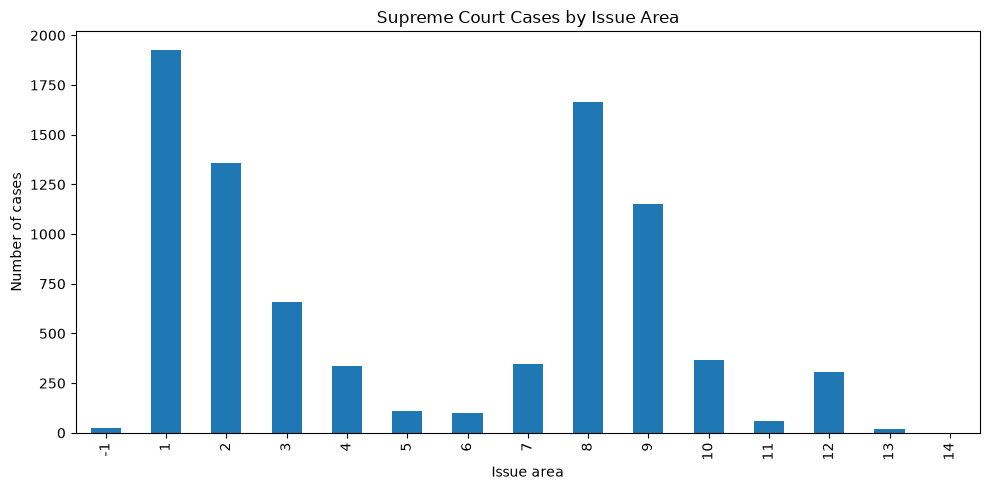

In [4]:
ax = issue_area_counts.plot(kind="bar", figsize=(10, 5))
ax.set_xlabel("Issue area")
ax.set_ylabel("Number of cases")
ax.set_title("Supreme Court Cases by Issue Area")
plt.tight_layout()
plt.savefig(results_dir / "issue_area_counts.png", dpi=150)
plt.show()

This bar chart compares the number of cases across issue-area classes and is saved to `../results/issue_area_counts.png`.

In [5]:
cases["text_length_words"] = cases["text"].fillna("").str.split().str.len()
cases["text_length_words"].describe()

count     8419.000000
mean      6960.610761
std       6273.806212
min          0.000000
25%       2826.000000
50%       5552.000000
75%       9365.500000
max      87247.000000
Name: text_length_words, dtype: float64

This summary describes the distribution of opinion lengths measured in words.

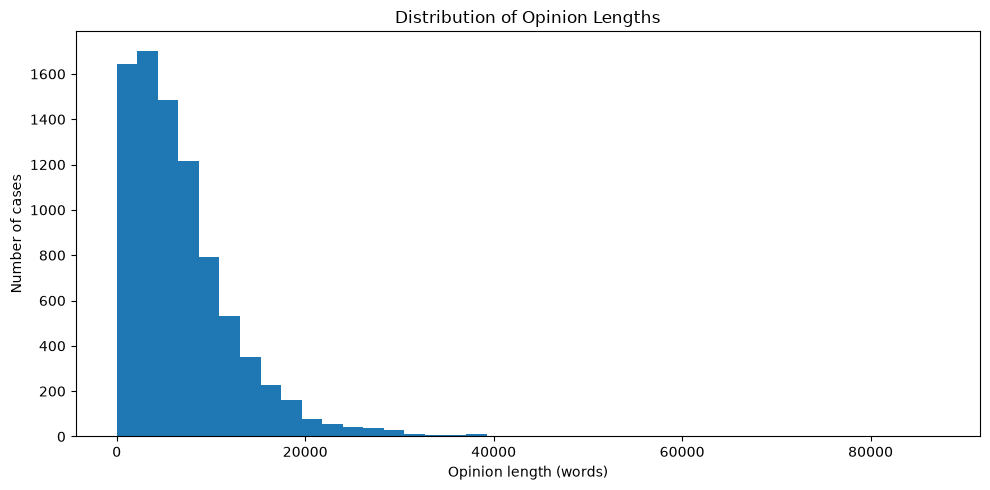

In [6]:
ax = cases["text_length_words"].plot(kind="hist", bins=40, figsize=(10, 5))
ax.set_xlabel("Opinion length (words)")
ax.set_ylabel("Number of cases")
ax.set_title("Distribution of Opinion Lengths")
plt.tight_layout()
plt.savefig(results_dir / "text_length_hist.png", dpi=150)
plt.show()

This histogram shows how frequently different opinion lengths occur and is saved to `../results/text_length_hist.png`.

In [7]:
few_sample_issue_areas = (issue_area_counts < 5).sum()
print("Issue-area classes with fewer than 5 samples:", few_sample_issue_areas)

Issue-area classes with fewer than 5 samples: 1


This counts issue-area classes represented by fewer than five cases.

In [8]:
cases["year"] = pd.to_numeric(cases["year"], errors="coerce")
cases["decade"] = (cases["year"] // 10 * 10).astype("Int64")
cases["decade"].value_counts().sort_index()

decade
1940     402
1950    1051
1960    1474
1970    1604
1980    1595
1990    1020
2000     788
2010     485
Name: count, dtype: Int64

This shows the number of cases decided in each decade.

The issue-area counts are imbalanced because some classes contain many more cases than others, so stratified splits and macro-F1 are important when evaluating classifiers.